# Artificial Neural Network 
##### 07/18/2026 Jiyun


In [1]:
# set random seed to have same result every run 
import tensorflow as tf

tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()

## Fashion MNIST

In [2]:
from tensorflow import keras

(train_input, train_target), (test_input, test_target) = keras.datasets.fashion_mnist.load_data()

#### load_data() - bring the train and test data separately. 

In [3]:
#Train Data 
print(train_input.shape, train_target.shape)

(60000, 28, 28) (60000,)


In [4]:
#Test Data 
print(test_input.shape, test_target.shape)

(10000, 28, 28) (10000,)


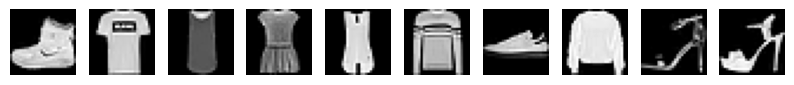

In [5]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 10, figsize=(10,10))
for i in range(10):
    axs[i].imshow(train_input[i], cmap='gray')
    axs[i].axis('off')
plt.show()

#### The dataset contains 60,000 images. Each image has a resolution of 28 × 28 pixels and is stored as a one-dimensional array.

In [6]:
print([train_target[i] for i in range(10)])

[9, 0, 0, 3, 0, 2, 7, 2, 5, 5]


In [7]:
#check unique value 
import numpy as np

print(np.unique(train_target, return_counts=True))

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8), array([6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000]))


## Classifying Fashion Items with Logistic Regression

In [8]:
#SDG Classifier / it doesn't have 2-dimensional array input 
# need Normalization
train_scaled = train_input / 255.0
#reshape - convert to 1 dimensional array 
train_scaled = train_scaled.reshape(-1, 28*28)

In [9]:
print(train_scaled.shape)

(60000, 784)


In [10]:
# Cross validation - Performance Evaluation
from sklearn.model_selection import cross_validate
from sklearn.linear_model import SGDClassifier

sc = SGDClassifier(loss='log_loss', max_iter=9, random_state=42)

scores = cross_validate(sc, train_scaled, train_target, n_jobs=-1)
print(np.mean(scores['test_score']))

/Users/jiyuncho/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_stochastic_gradient.py:702: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/Users/jiyuncho/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_stochastic_gradient.py:702: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/Users/jiyuncho/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_stochastic_gradient.py:702: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/Users/jiyuncho/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_stochastic_gradient.py:702: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


0.8304


/Users/jiyuncho/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_stochastic_gradient.py:702: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


##### max_iter = 5 , 0.81 
##### max_iter = 9 , 0.83

## Artifical Neural Network 

### Tensorflow and Keras 

##### deep learning library - tensorflow 

In [11]:
import tensorflow as tf

In [12]:
from tensorflow import keras

## simple classification using keras API

In [13]:
from sklearn.model_selection import train_test_split

train_scaled, val_scaled, train_target, val_target = train_test_split(
    train_scaled, train_target, test_size=0.2, random_state=42)

In [14]:
print(train_scaled.shape, train_target.shape)

(48000, 784) (48000,)


In [15]:
print(val_scaled.shape, val_target.shape)

(12000, 784) (12000,)


In [ ]:
#The number of fashion item = 10 
#Activation function = softmax

In [16]:
dense = keras.layers.Dense(10, activation='softmax', input_shape=(784,))

/Users/jiyuncho/anaconda3/lib/python3.11/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [17]:
model = keras.Sequential([dense])

## 인공신경망으로 패션 아이템 분류하기

##### sparse_categorical_crossentropy =  Compute the cross entropy loss using integer encoded target labels.

##### Metrics ->  Monitor Accuracy as a Training Metric

In [18]:
model.compile(loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [19]:
print(train_target[:10])

[7 3 5 8 6 9 3 3 9 9]


In [20]:
model.fit(train_scaled, train_target, epochs=5)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 572us/step - accuracy: 0.7370 - loss: 0.7853
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 570us/step - accuracy: 0.8346 - loss: 0.4845
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 566us/step - accuracy: 0.8452 - loss: 0.4564
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 565us/step - accuracy: 0.8504 - loss: 0.4425
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 570us/step - accuracy: 0.8537 - loss: 0.4337


In [ ]:
# evaluates -> to check the performance
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 556us/step - accuracy: 0.8462 - loss: 0.4364


[0.4444445073604584, 0.8458333611488342]

- **Epoch**: One complete pass through the entire training dataset.
- **Batch**: A small subset of the training data fed into the model at one time.
- **Iteration**: A single update of the model's parameters after processing one batch.